# **RDKit Molecular Clustering & Drug Prediction**
This notebook performs **molecular clustering** and **drug prediction** using RDKit, scikit-learn, and ChEMBL API.

In [6]:

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from chembl_webresource_client.new_client import new_client
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
%matplotlib inline


In [7]:

# Function to generate Morgan fingerprints (optimized)
def get_fingerprint(smiles, radius=2, fp_size=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        gen = GetMorganGenerator(radius=radius, fpSize=fp_size)
        fp = np.array(gen.GetFingerprint(mol))
        return fp  # Returning full fingerprint
    return None

# Example molecules
smiles_list = [
    "CC(C)C(C(=O)O)N",  # Alanine
    "CC1=CC=CC=C1O",  # Phenol
    "CCN(CC)C(=O)NC1=CC=CC=C1"  # Acetanilide
]

# Generate fingerprints
fingerprints = np.array([get_fingerprint(smiles) for smiles in smiles_list])


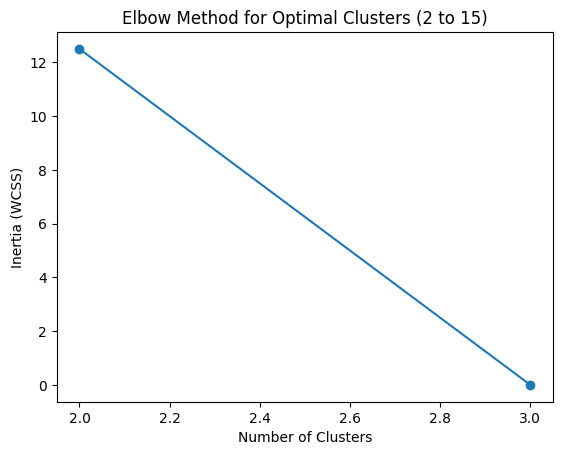

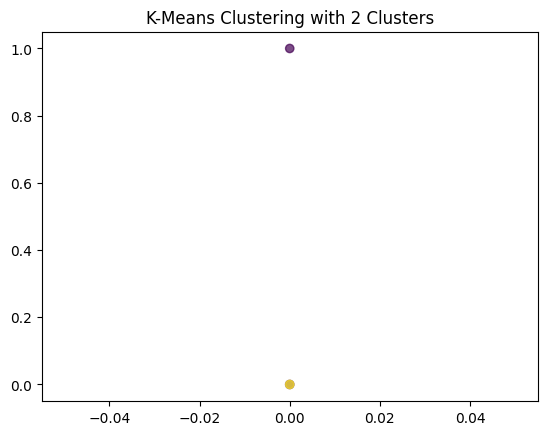

In [8]:

# Finding the optimal number of clusters using the Elbow method
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
cluster_range = np.arange(2, 16)  # Range from 2 to 15 clusters

for k in cluster_range:
    if k > len(fingerprints):  # Prevents clusters > available molecules
        break
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(fingerprints)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(cluster_range[:len(inertia)], inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal Clusters (2 to 15)")
plt.show()

# Determine the optimal cluster count using the minimum elbow point
optimal_k = cluster_range[np.argmin(np.diff(inertia))]
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(fingerprints)

# Visualizing Clusters
plt.scatter(fingerprints[:, 0], fingerprints[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.title(f"K-Means Clustering with {optimal_k} Clusters")
plt.show()


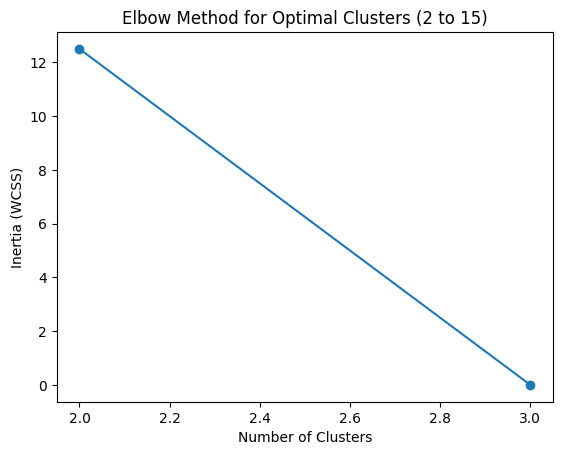

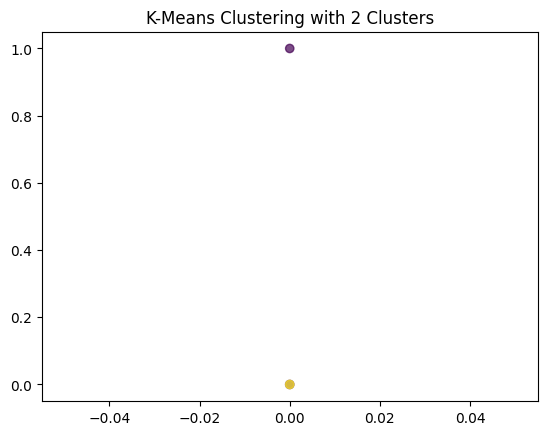

In [9]:

# Finding the optimal number of clusters using the Elbow method
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
cluster_range = np.arange(2, 16)  # Range from 2 to 15 clusters

for k in cluster_range:
    if k > len(fingerprints):  # Prevents clusters > available molecules
        break
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(fingerprints)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(cluster_range[:len(inertia)], inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal Clusters (2 to 15)")
plt.show()

# Determine the optimal cluster count using the minimum elbow point
optimal_k = cluster_range[np.argmin(np.diff(inertia))]
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(fingerprints)

# Visualizing Clusters
plt.scatter(fingerprints[:, 0], fingerprints[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.title(f"K-Means Clustering with {optimal_k} Clusters")
plt.show()


In [ ]:

import random

# Function to predict drug based on exactly 3 fingerprints in a cluster
def predict_three_fingerprint_drug(cluster_id):
    cluster_indices = np.where(clusters == cluster_id)[0]

    if len(cluster_indices) < 3:
        print(f"Cluster {cluster_id} has less than 3 molecules, skipping...")
        return None

    # Randomly select three fingerprints from the cluster
    selected_indices = random.sample(list(cluster_indices), 3)
    selected_fps = fingerprints[selected_indices]

    # Combine three fingerprints using OR operation
    combined_fp = np.bitwise_or.reduce(selected_fps)
    combined_fp = combined_fp / np.sum(combined_fp)  # Normalize

    # Convert to RDKit BitVector
    combined_bv = numpy_to_bitvector(combined_fp)

    # Find best match using Tanimoto similarity
    best_match = None
    best_score = 0
    for molecule in chembl_molecules:
        mol_fp = get_fingerprint(molecule['molecule_structures']['canonical_smiles'])
        if mol_fp is not None:
            mol_bv = numpy_to_bitvector(mol_fp)
            similarity = TanimotoSimilarity(combined_bv, mol_bv)
            if similarity > best_score:
                best_score = similarity
                best_match = molecule

    return best_match

# Example: Predict drug for Cluster 0 using 3 fingerprints
predicted_drug = predict_three_fingerprint_drug(1)
print(predicted_drug)


Cluster 1 has less than 3 molecules, skipping...
None
